# 01 - Exploratory Data Analysis (EDA)
**Capstone Project - Machine Learning UAS**
Nama: Laily Muthia N | NIM: A11.2024.15618

Dataset: Heart Failure Prediction Dataset (Kaggle - fedesoriano)
CRISP-DM Tahap 2: **Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Statistik Deskriptif Awal

In [2]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
df.info()

Jumlah baris : 918
Jumlah kolom : 12
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


## 2. Analisis Kualitas Data (Missing Values, Duplikat, Anomali)

In [4]:
print("Missing values per kolom:")
print(df.isnull().sum())
print("\nJumlah duplikat:", df.duplicated().sum())

# Cek nilai 0 yang tidak wajar secara klinis
for col in ["Cholesterol", "RestingBP"]:
    n_zero = (df[col] == 0).sum()
    print(f"{col} = 0: {n_zero} baris ({n_zero/len(df)*100:.1f}%)")

Missing values per kolom:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Jumlah duplikat: 0
Cholesterol = 0: 172 baris (18.7%)
RestingBP = 0: 1 baris (0.1%)


**Temuan:** Dataset tidak memiliki missing value eksplisit maupun duplikat, namun terdapat 172 baris (18.7%) dengan Cholesterol = 0 dan 1 baris dengan RestingBP = 0 — keduanya mustahil secara klinis, sehingga diperlakukan sebagai *hidden missing values* yang perlu diimputasi pada tahap Data Preparation.

## 3. Distribusi Target (Class Imbalance Check)

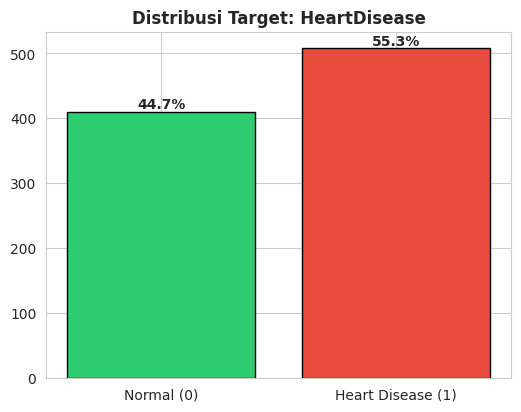

Rasio ketidakseimbangan kelas: 1.24:1


In [5]:
counts = df["HeartDisease"].value_counts().sort_index()
pct = df["HeartDisease"].value_counts(normalize=True).sort_index()*100

fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(["Normal (0)","Heart Disease (1)"], counts.values, color=["#2ecc71","#e74c3c"], edgecolor="black")
for b,p in zip(bars, pct.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f"{p:.1f}%", ha="center", fontweight="bold")
ax.set_title("Distribusi Target: HeartDisease", fontweight="bold")
plt.show()

ratio = counts.max()/counts.min()
print(f"Rasio ketidakseimbangan kelas: {ratio:.2f}:1")

**Temuan:** Distribusi kelas relatif seimbang (rasio ±1.24:1), namun tetap perlu dievaluasi dengan F1-Score agar tidak bias terhadap kelas mayoritas.

## 4. Distribusi & Outlier Fitur Numerik

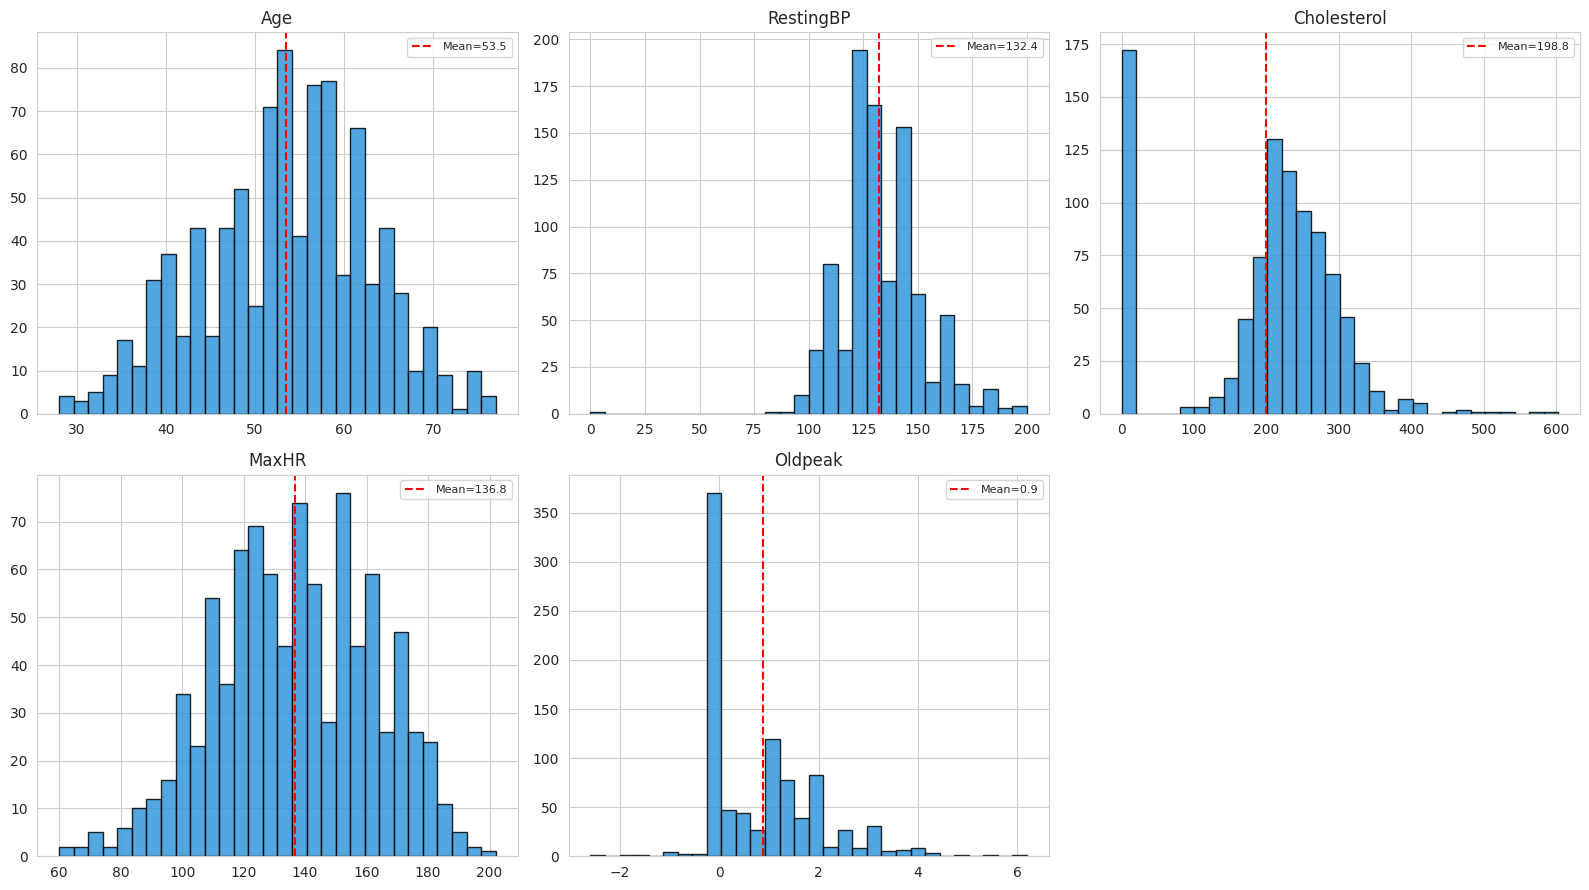

In [6]:
numeric_cols = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="#3498db", edgecolor="black", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean={df[col].mean():.1f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

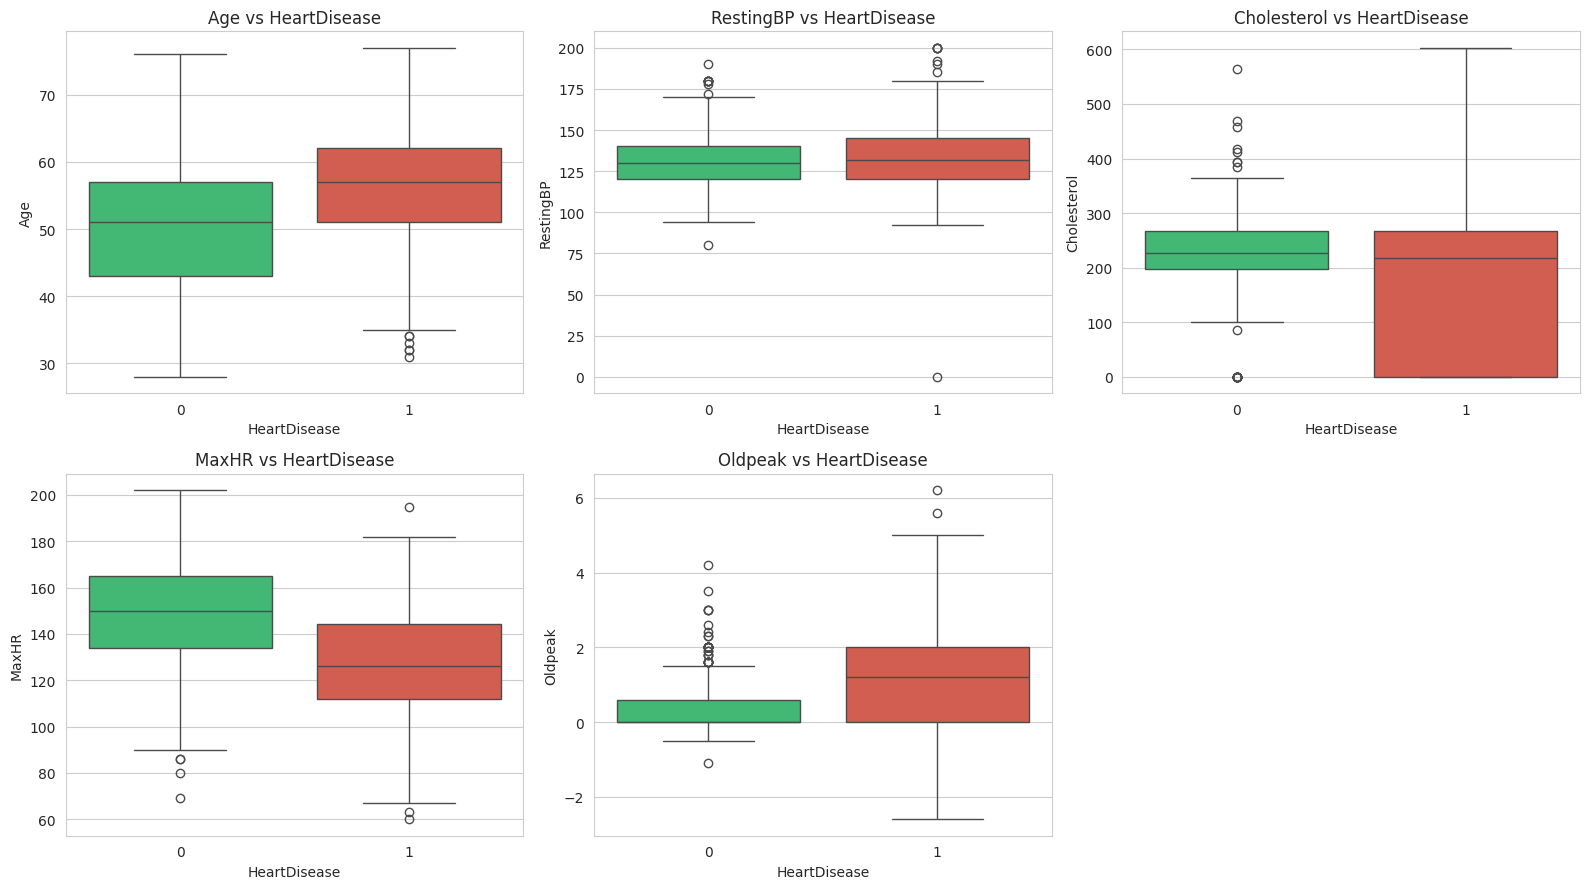

In [7]:
fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()
for i,col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="HeartDisease", y=col, hue="HeartDisease", palette=["#2ecc71","#e74c3c"], legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs HeartDisease")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 5. Distribusi Fitur Kategorikal vs Target

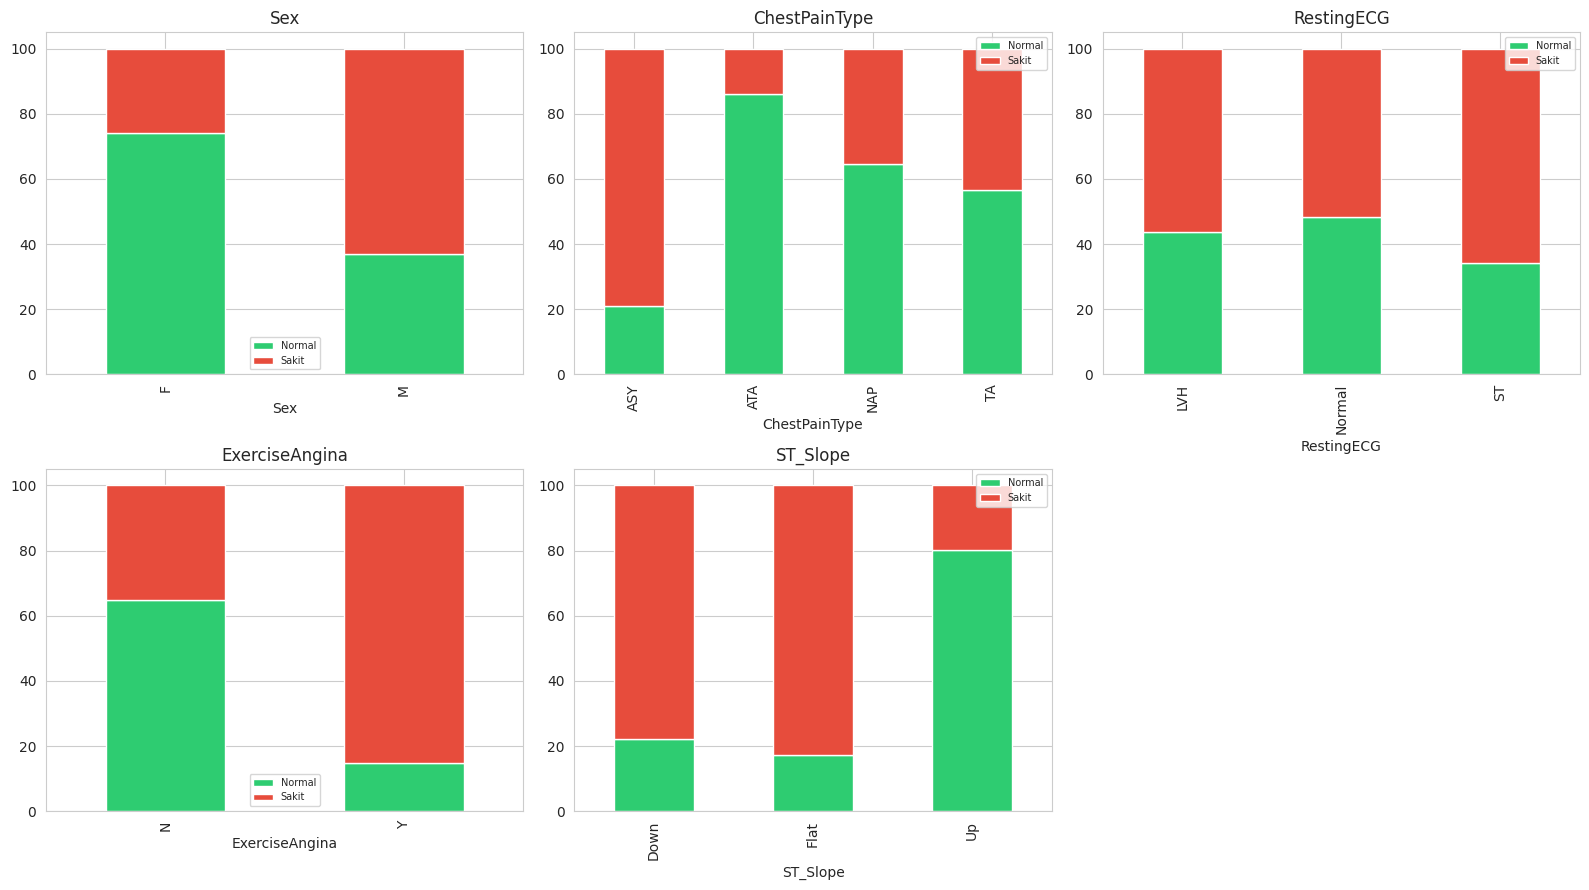

In [8]:
cat_cols = ["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"]
fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["HeartDisease"], normalize="index")*100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["#2ecc71","#e74c3c"])
    axes[i].set_title(col)
    axes[i].legend(["Normal","Sakit"], fontsize=7)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Temuan:** ST_Slope 'Flat' dan ChestPainType 'ASY' (asymptomatic) menunjukkan proporsi Heart Disease jauh lebih tinggi — kandidat fitur kategorikal paling prediktif.

## 6. Korelasi Antar Fitur (Multikolinearitas)

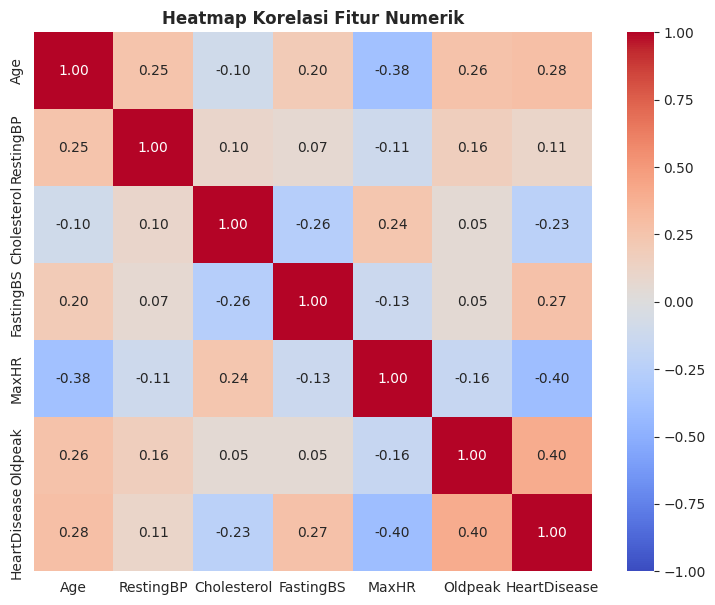

Korelasi terhadap target (diurutkan):
Oldpeak        0.403951
MaxHR         -0.400421
Age            0.282039
FastingBS      0.267291
Cholesterol   -0.232741
RestingBP      0.107589
Name: HeartDisease, dtype: float64


In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)
plt.title("Heatmap Korelasi Fitur Numerik", fontweight="bold")
plt.show()

print("Korelasi terhadap target (diurutkan):")
print(corr["HeartDisease"].drop("HeartDisease").sort_values(key=abs, ascending=False))

## 7. Ringkasan 5 Insight Utama

1. **Ketidakseimbangan kelas ringan**: 55.3% Heart Disease vs 44.7% Normal (rasio 1.24:1) → gunakan F1-Score.
2. **Nilai 0 tidak wajar secara klinis** pada Cholesterol (18.7%) dan RestingBP → perlu imputasi median per kelas.
3. **Oldpeak (+0.40)** dan **MaxHR (-0.40)** adalah fitur numerik paling berkorelasi dengan target.
4. **ST_Slope 'Flat'** dan **ChestPainType 'ASY'** paling diskriminatif secara kategorikal.
5. **Tidak ada multikolinearitas ekstrem** (korelasi < 0.8) antar fitur numerik → aman digunakan bersama tanpa PCA.

Insight ini menjadi dasar strategi *feature engineering* dan *preprocessing* pada notebook berikutnya (`02_modeling.ipynb`).